In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Getting Data

In [5]:
df = pd.read_csv("Books_Data_Clean.csv")

In [6]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


Analyzing Dataset
Summarizing Data.

In [7]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


Fixing Publishing Year

In [8]:
df = df[df["Publishing Year"] > 1900]

To check if there any NA values

In [9]:
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,21
Author,0
language_code,49
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


Dropping data with No Books Name but keeping data which has No language code as there can be book of high ratings.

In [10]:
df.dropna(subset = "Book Name",inplace = True)

Checking Duplicated values

In [11]:
df.duplicated().sum()

np.int64(0)

Checking unique entries in each column.

In [12]:
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


Creating histogram of Publishing year to understand Distribution.

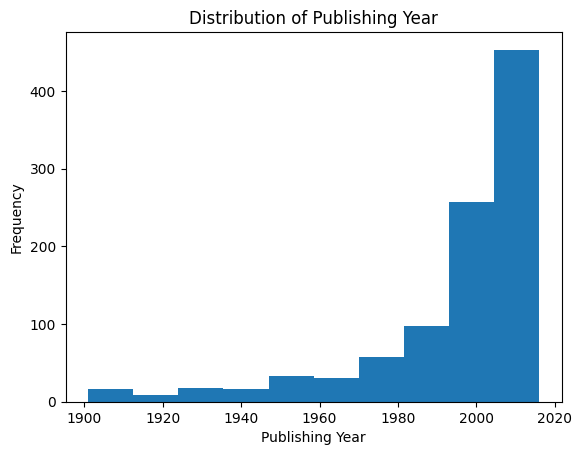

In [13]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

Conclusion:Data contains newly Published Books


Creating Bar Chart to show no.of Books in each genre

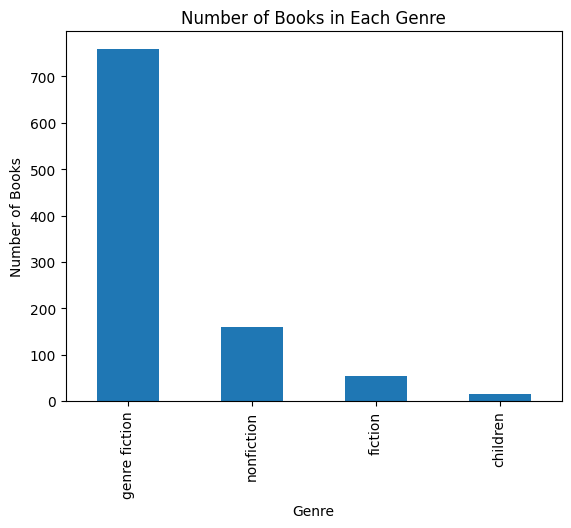

In [14]:
df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of Books in Each Genre")
plt.show()

Conclusion:There is high no.of Books in genre fiction (almost 75%)

Groupby Author and average rating for each author

In [15]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending = False).head(5)

,Book_average_rating
Author,
Bill Watterson,4.650
"Bill Watterson, G.B. Trudeau",4.610
J.R.R. Tolkien,4.590
George R.R. Martin,4.560
Sarah J. Maas,4.526


Conclusion:Top 5 Authors with highest Book_average_rating.

Books rating count for each genre

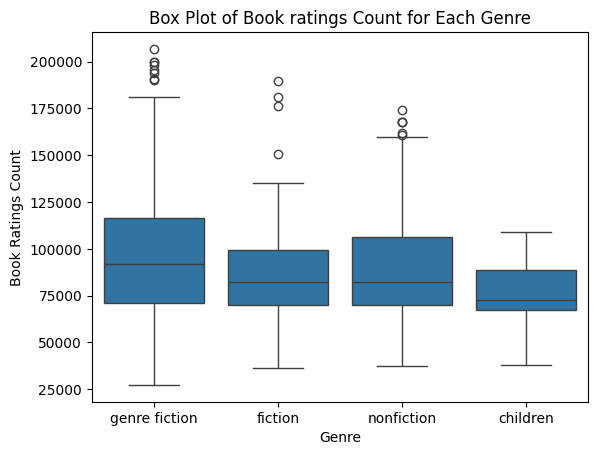

In [16]:
sns.boxplot(x = "genre",y = "Book_ratings_count",data = df)
plt.xlabel("Genre")
plt.ylabel("Book Ratings Count")
plt.title("Box Plot of Book ratings Count for Each Genre")
plt.show()

The genre fiction category displays the highest median rating count and the largest overall variance (widest IQR), with multiple high-volume outliers extending past 200,000 ratings. Fiction and non-fiction show a similar, fairly symmetrical distribution of baseline data, though both feature multiple upper-bound outliers. In contrast, the children genre shows a tighter, narrower distribution with zero outliers, indicating a highly predictable and consistent rating count.

Scatter Plot of Sale Price and Unit Sold.

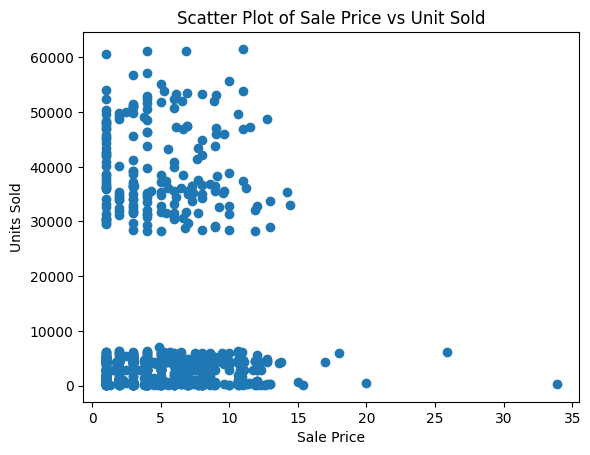

In [17]:
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter Plot of Sale Price vs Unit Sold")
plt.show()

Conclusion:Less sale price books sold more unit.

Value count of language code

In [18]:
language_counts = df["language_code"].value_counts()

Pie Chart of language distribution.

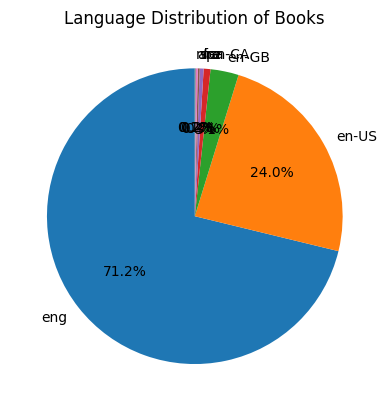

In [19]:
plt.pie(language_counts,labels = language_counts.index,startangle = 90,autopct="%1.1f%%")
plt.title("Language Distribution of Books")
plt.show()

Conclusion:English language books dominates the data.

Group data by publisher and calculate total revenue

In [20]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending= False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


Conclusion:Highest revenue is Penguin Group(USA) and lowest is HarperCollins Christian Publishing.

Group by data by author rating and find average book ratings count.

In [21]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False)

,Book_ratings_count
Author_Rating,
Intermediate,101400.272569
Famous,98295.250000
Novice,87318.464286
Excellent,83804.800595


Conclusion:When evaluating the average volume of ratings per book,books written by Intermediate authors yield the highest average rating count (~ 101400),marginally outperforming Famous authors (~ 98,295).Interestingly,Excellent rated authors average the lowest overall rating count (~ 83804) despite their higher individual unit sales potential observed previously.

Scatter plot of Book average rating and book ratings count

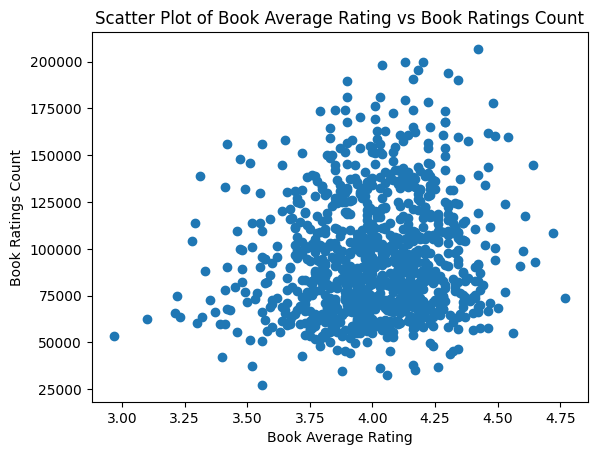

In [22]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter Plot of Book Average Rating vs Book Ratings Count")
plt.show()

Conclusion:"The scatter plot reveals a weak linear correlation between a book's average rating and its total ratings count. The vast majority of titles cluster between a 3.5 and 4.4 rating. Furthermore, we observe that highly reviewed books (above 150,000 counts) rarely hold extreme high or low scores, converging instead toward a centralized average of approximately 4.0 due to the diverse opinions of a large reader base."

Bar Chart of total gross sales for each author

In [23]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum().head(20)

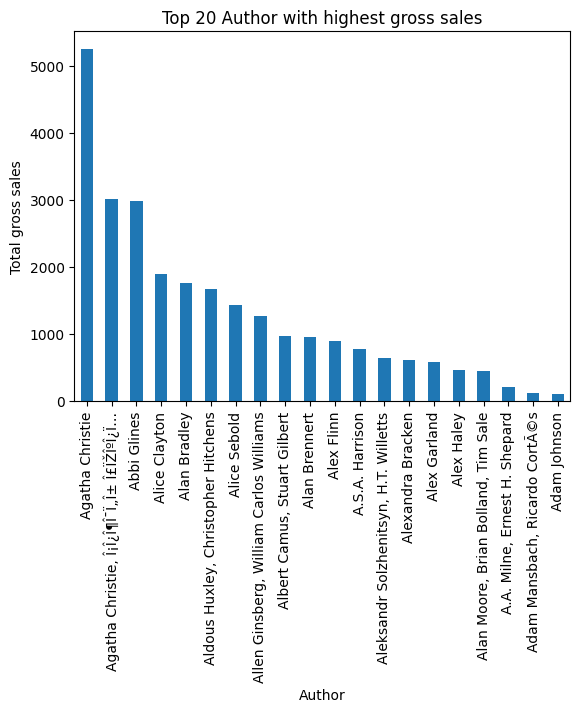

In [24]:
total_gross_sales_by_author.sort_values(ascending = False).head(20).plot(kind = "bar")
plt.xlabel("Author")
plt.ylabel("Total gross sales")
plt.title("Top 20 Author with highest gross sales")
plt.show()

Conclusion:Harper Lee tops the list.

Boxplot of unit sold for each Author rating

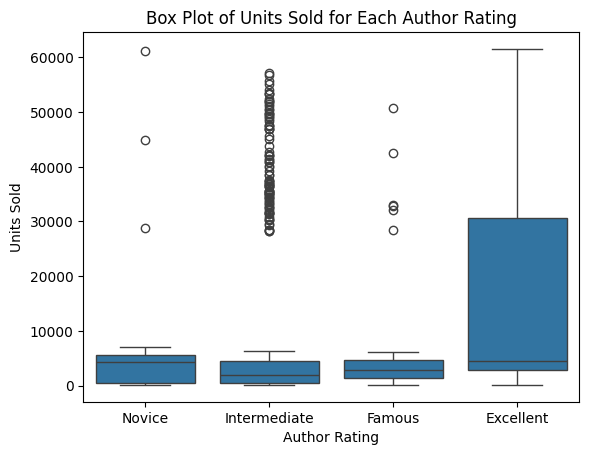

In [25]:
sns.boxplot(x = "Author_Rating",y = "units sold",data = df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.title("Box Plot of Units Sold for Each Author Rating")
plt.show()

Conclusion:Authors with an Excellent rating achieve the highest overall performance, boasting both the highest median sales and a massive upper-bound distribution where many authors dramatically outperform all other tiers. On the other hand, while the typical Intermediate author maintains low baseline sales, a select group of high-performing individuals break the category expectations entirely, generating massive sales volumes that manifest as a dense cluster of upper-bound outliers.

line chart using groupby of publishing year and total units

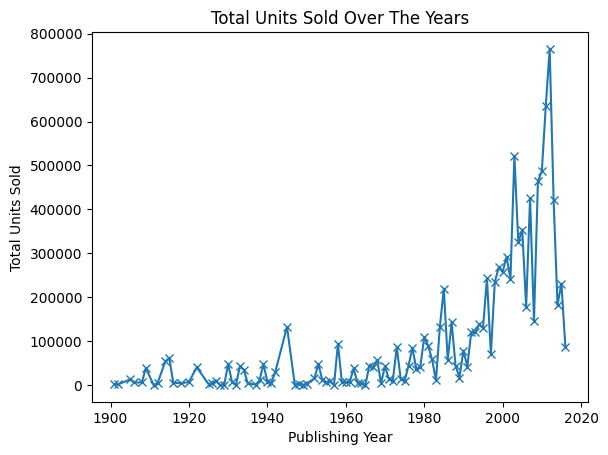

In [26]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line",marker = "x")
plt.xlabel("Publishing Year")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold Over The Years")
plt.show()

Conclusion:From 1900 until the late 1970s, sales remained relatively flat and low. However, starting in the 1980s, the dataset exhibits a clear, long-term upward trend in sales volume. This growth accelerates exponentially post-2000, reaching an all-time peak of over 750,000 units sold around 2012. Notably, the modern era (2000–2020) also introduces significant volatility, characterized by sharp year-over-year fluctuations despite the higher overall sales baseline.
